# FRAUD DETECTION ANALYSIS

### IMPORTING THE NECESSARY LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv("AIML Dataset.csv")

### CHECKING THE MAKE UP OF MY DATASET

In [7]:
df.shape

(1048575, 11)

In [8]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


In [10]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

### Checking the number of fraud detected as against the number not detected ###

In [12]:
df["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

* In here, we find out that 1142 values were detected as fraud and 1047433 were not 

In [14]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    1048575
Name: count, dtype: int64

* In here, we find out that none of the values were flagged as fraud

In [16]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

* In here, we find out that none of the columns have null values 

In [18]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)

0.11

* In here, we checked the percentage of fraud in the entire dataset

### Visualization

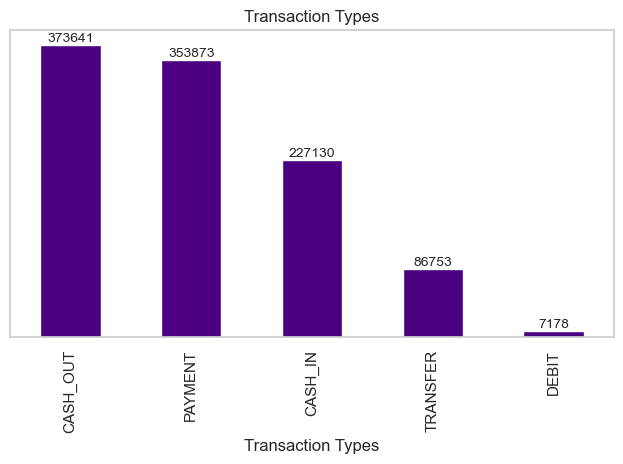

In [21]:
ax = df["type"].value_counts().plot(kind="bar", title="Transaction Types", color = "Indigo")
plt.xlabel("Transaction Types")
ax.grid(False)


ax.get_yaxis().set_visible(False)

for bar in ax.patches:
    ax.annotate(
        str(int(bar.get_height())),
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=10
    )


plt.tight_layout()
plt.show()

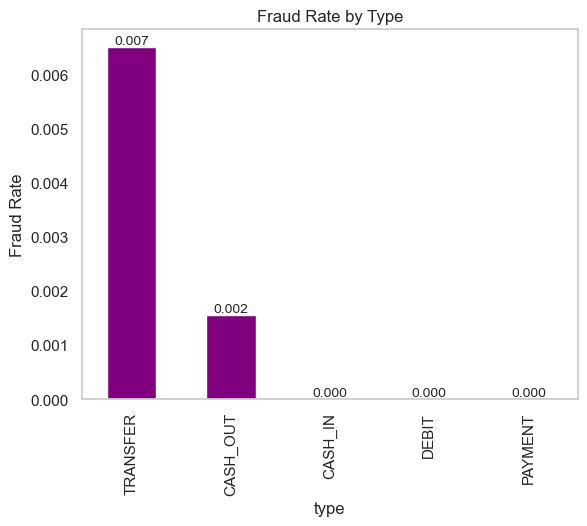

In [22]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
ft = fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="Purple")
ft.grid(False)

for bar in ft.patches:
    ft.annotate(
        f"{bar.get_height():.3f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.ylabel("Fraud Rate")
plt.show()

In [23]:
fraud_by_type

type
TRANSFER    0.006501
CASH_OUT    0.001547
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [24]:
df["amount"].describe().astype(int)

count     1048575
mean       158666
std        264940
min             0
25%         12149
50%         76343
75%        213761
max      10000000
Name: amount, dtype: int32

# Distribution of the Transaction Amount 

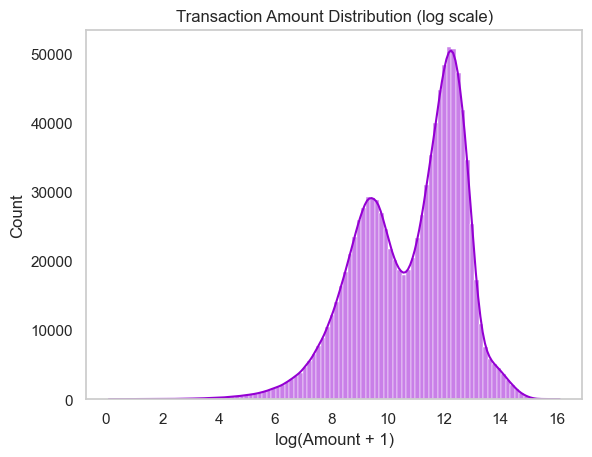

In [26]:
td = sns.histplot(np.log1p(df["amount"]), bins=100, kde = True, color = "darkviolet")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("log(Amount + 1)")
td.grid(False)
plt.show()

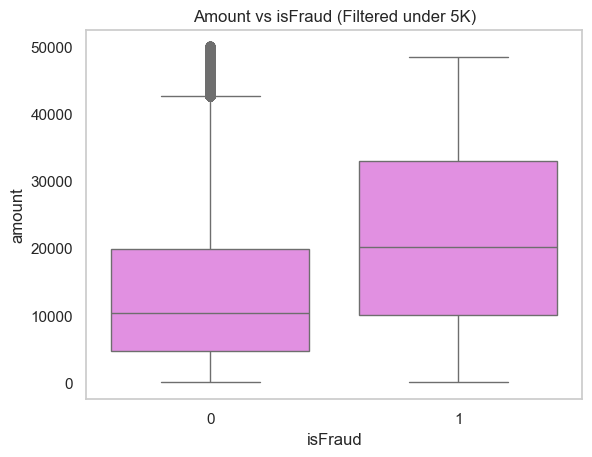

In [27]:
sns.boxplot(data= df[df["amount"]< 50000], x="isFraud", y="amount", color= "Violet")
plt.title("Amount vs isFraud (Filtered under 5K)")
plt.grid(False)
plt.show()

In [46]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [60]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [62]:
(df["balanceDiffOrig"] < 0).sum()

227102

In [64]:
(df["balanceDiffDest"] < 0).sum()

204144

In [66]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDest,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.0


* Dropping the step column

In [69]:
df.drop(columns="step", inplace=True)

In [73]:
df.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDest,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.0


* Exploring the type of Customer per transaction

In [76]:
top_senders = df["nameOrig"].value_counts().head(10)

In [78]:
top_senders

nameOrig
C1214450722    2
C309111136     2
C1268675361    2
C720460198     2
C1109092856    2
C545402485     2
C1362689728    2
C110179857     2
C1467095135    2
C2073023524    2
Name: count, dtype: int64

In [80]:
top_receivers = df["nameDest"].value_counts().head(10)

In [82]:
top_receivers

nameDest
C985934102     98
C1286084959    96
C1590550415    89
C248609774     88
C665576141     87
C2083562754    86
C977993101     82
C1360767589    81
C451111351     80
C306206744     79
Name: count, dtype: int64

In [84]:
fraud_users = df[df["isFraud"]== 1]["nameOrig"].value_counts().head(10)

In [88]:
fraud_users

nameOrig
C1305486145    1
C1776675634    1
C289101217     1
C1116093088    1
C1795901064    1
C1422133318    1
C1694539503    1
C1198248537    1
C1837436553    1
C1422380255    1
Name: count, dtype: int64

In [90]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [94]:
fraud_types["type"].value_counts()

type
CASH_OUT    373641
TRANSFER     86753
Name: count, dtype: int64

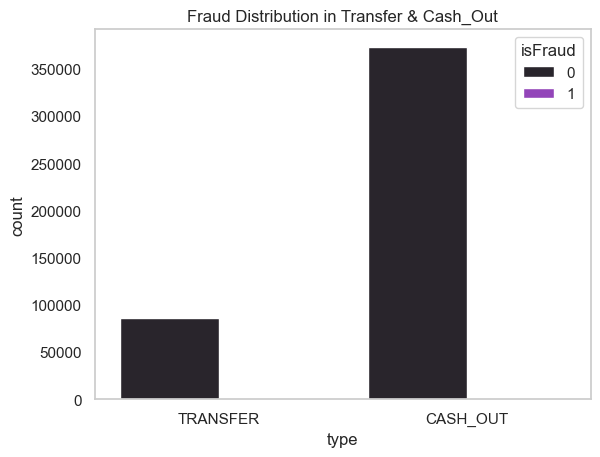

In [110]:
sns.countplot(data=fraud_types, x="type", hue="isFraud", color= "darkorchid")
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.grid(False)
plt.show()

* Finding the Correlation between various accounts

In [108]:
corr = df[["amount", "oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [112]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.004864,-0.001132,0.215562,0.311942,0.128862
oldbalanceOrg,0.004864,1.000000,0.999050,0.093305,0.064050,0.003829
newbalanceOrig,-0.001132,0.999050,1.000000,0.095179,0.063722,-0.009438
oldbalanceDest,0.215562,0.093305,0.095179,1.000000,0.978401,-0.007553
newbalanceDest,0.311942,0.064050,0.063722,0.978401,1.000000,-0.000495
isFraud,0.128862,0.003829,-0.009438,-0.007553,-0.000495,1.000000


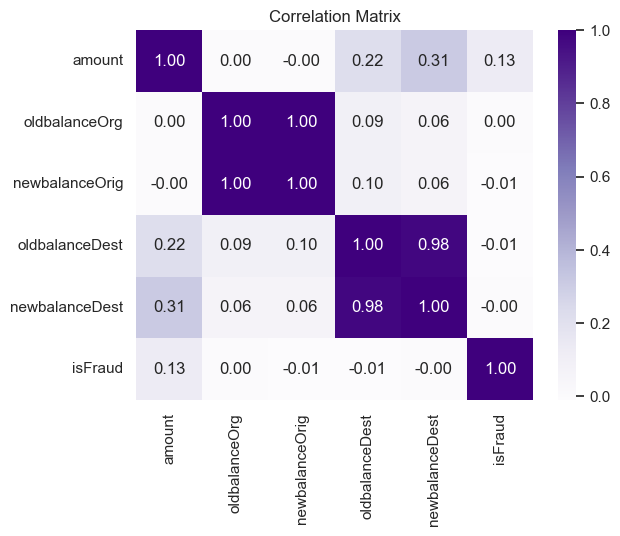

In [121]:
sns.heatmap(corr, annot=True, cmap = "Purples", fmt= ".2f")
plt.title("Correlation Matrix")
plt.show()

In [127]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [129]:
len(zero_after_transfer)

192858

In [131]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDest,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89,2712905.89


In [133]:
df["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

* MODEL

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [141]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDest,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0.0


In [145]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)

In [147]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDest,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0,0.0


In [149]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [153]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, stratify=y)

In [159]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder= "drop"
)

In [163]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [167]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [171]:
y_pred = pipeline.predict(X_test)

In [175]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97    314230
           1       0.02      0.99      0.03       343

    accuracy                           0.93    314573
   macro avg       0.51      0.96      0.50    314573
weighted avg       1.00      0.93      0.96    314573



In [177]:
confusion_matrix(y_test,y_pred)

array([[293325,  20905],
       [     5,    338]], dtype=int64)

In [181]:
pipeline.score(X_test, y_test)*100

93.35289424076446

In [183]:
import joblib

joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']